<div align="center">

# Assignment 9

</div>

# Autoencoders and Variational Autoencoders

Deadline: May 26, 2026

# 🎯 Objective

The goal of this assignment is to:

* understand the basic idea of an **autoencoder** as an encoder-decoder model,
* compare a simple linear autoencoder with **PCA**,
* train a **denoising autoencoder** on Fashion-MNIST,
* practice the first mathematical ideas behind **Variational Autoencoders**,
* calculate simple KL divergence terms used in VAE training,
* implement the **reparameterization trick**,
* optionally try inference with a pretrained VAE decoder/encoder from Hugging Face Diffusers.

This assignment is connected to [Lecture 11, May 19](/doc/6df8323e-5acb-41a3-bc52-294cdff8e80a) : Autoencoders and Variational Autoencoders.


---

# 📌 General Requirements

* Use **PyTorch** and **TorchVision**.
* Submit a **Jupyter Notebook (.ipynb)**.
* The notebook must:
  * run from top to bottom without errors,
  * include markdown explanations,
  * include plots where required,
  * set a random seed,
  * use clear variable names,
  * be reproducible.

You may use GPU if available, but the assignment should also be possible on CPU if you use small models and/or subsets of the data.


---

# ⚠ Restrictions

✅ Allowed:

* `torch.nn.Module`
* `torch.optim`
* `torch.utils.data.DataLoader`
* `torchvision.datasets.FashionMNIST`
* `torchvision.transforms`
* `matplotlib`
* `numpy`
* `sklearn.decomposition.PCA` only for the PCA comparison in Task 1
* Hugging Face `diffusers` only for the optional pretrained VAE inference part

❌ Not allowed:

* high-level training frameworks such as Lightning, fastai, or Trainer APIs,
* copying a full autoencoder/VAE implementation from the internet without explanation,
* using a pretrained model for Tasks 1 or 2,
* skipping the training loop.

You must write:

* the model class,
* the forward pass,
* the loss computation,
* the training loop,
* the evaluation / visualization code,
* the discussion of results.


---

# 📚 Recommended Reading

Before starting, review:

* [PyTorch `torch.nn.Module`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html)
* [TorchVision Fashion-MNIST dataset](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html)
* [scikit-learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
* [Hugging Face Diffusers `AutoencoderKL`](https://huggingface.co/docs/diffusers/api/models/autoencoderkl)

Note: TorchVision provides many pretrained models for classification, detection, segmentation, video, and optical flow, but it does not provide a standard pretrained VAE model in the same way it provides pretrained ResNet or MobileNet models. For pretrained VAE inference, use Hugging Face Diffusers.


---

# Task 1 — Linear autoencoder and PCA on 3D data (3 pts)

In this task, you will train a very small autoencoder with architecture:

$$
3 \rightarrow 2 \rightarrow 3
$$

The goal is to compress 3-dimensional data into a 2-dimensional latent representation and reconstruct the original input.

A linear autoencoder trained with mean squared error learns a low-dimensional subspace similar to PCA. The exact coordinates in the latent space may be different, but the reconstruction quality and the learned subspace should be comparable.


---

## Dataset

Generate a simple 3D dataset with strong correlation between coordinates.

Example:

```python
import torch

torch.manual_seed(42)

n = 1000

u = torch.randn(n, 1)
v = torch.randn(n, 1)

x1 = u
x2 = 0.5 * u + v
x3 = 2.0 * u - 0.3 * v + 0.1 * torch.randn(n, 1)

X = torch.cat([x1, x2, x3], dim=1)

# Center the data
X = X - X.mean(dim=0, keepdim=True)
```

Each sample has shape:

$$
x \in \mathbb{R}^3
$$

The latent representation has shape:

$$
z \in \mathbb{R}^2
$$


---

## Requirements


1. Create a **linear autoencoder**:

```python
encoder: Linear(3, 2)
decoder: Linear(2, 3)
```

Do not use nonlinear activations in this task.


2. Train the autoencoder using:
   * `MSELoss`,
   * an optimizer from `torch.optim`,
   * at least 500 training steps.
3. Plot:
   * training loss vs iteration,
   * original 3D points,
   * reconstructed 3D points,
   * 2D latent codes produced by the encoder.
4. Fit PCA with 2 components to the same centered data.
5. Compare:
   * reconstruction MSE of the autoencoder,
   * reconstruction MSE of PCA.
6. Print a small table:

| Method | Latent dimension | Reconstruction MSE |
|--------|-----------------:|-------------------:|
| Linear AE | 2                | ...                |
| PCA    | 2                | ...                |


---

## Required discussion

Explain:

* what the encoder learns,
* what the decoder learns,
* why the bottleneck forces compression,
* why the result should be similar to PCA,
* why the latent coordinates of the autoencoder do not have to be identical to PCA coordinates,
* whether the autoencoder and PCA reached similar reconstruction errors.


---

Dataset shape: torch.Size([1000, 3])
Final AE training loss: 0.009296


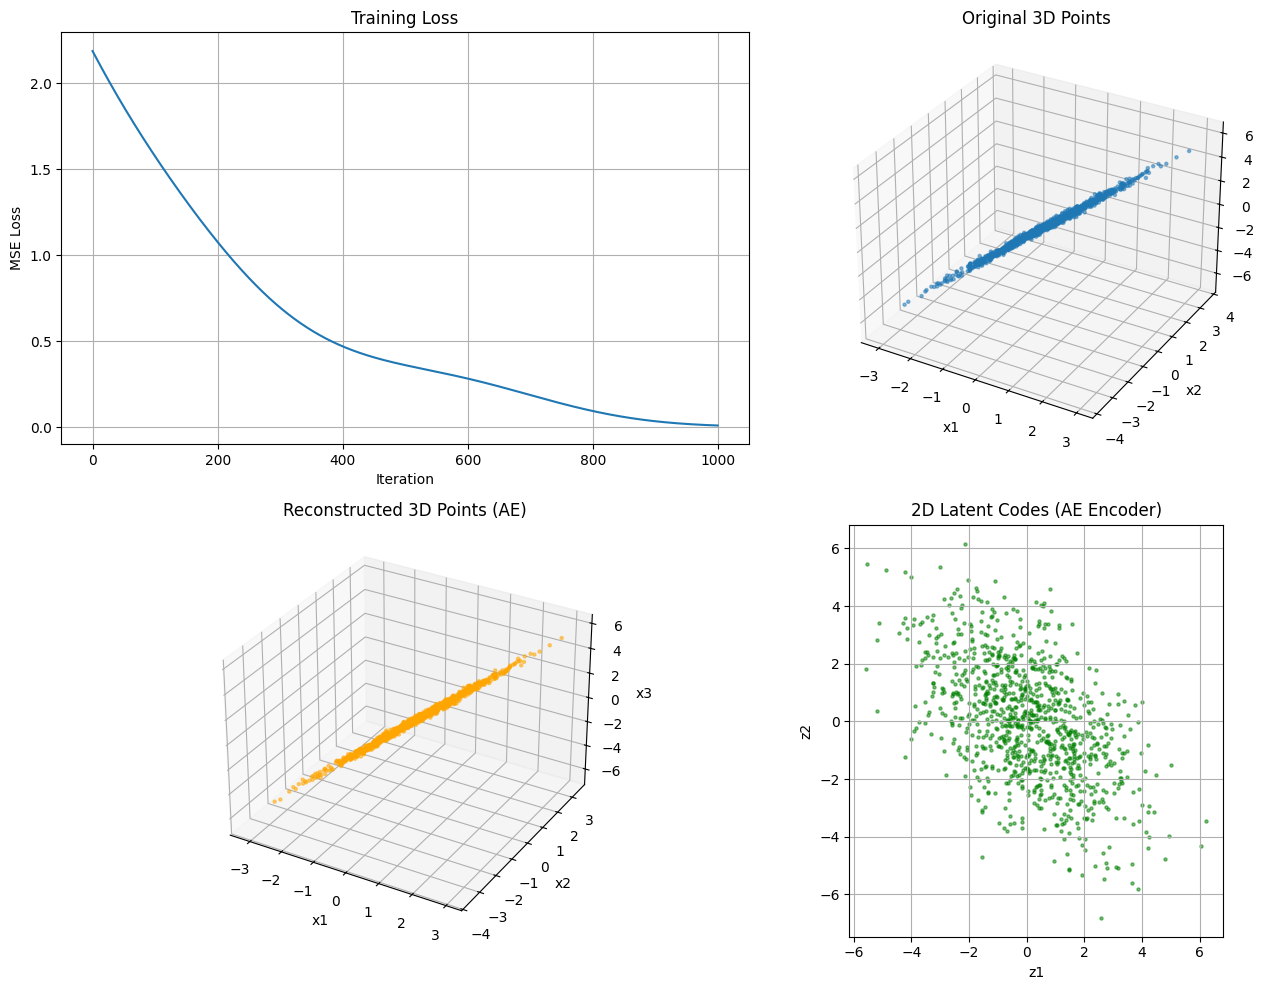


Method            Latent dim   Reconstruction MSE
-------------------------------------------------------
Linear AE                  2             0.009168
PCA                        2             0.000579


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# 1. Generate 3D dataset
# ============================================================
n = 1000
u = torch.randn(n, 1)
v = torch.randn(n, 1)

x1 = u
x2 = 0.5 * u + v
x3 = 2.0 * u - 0.3 * v + 0.1 * torch.randn(n, 1)

X = torch.cat([x1, x2, x3], dim=1)
X = X - X.mean(dim=0, keepdim=True)

print(f"Dataset shape: {X.shape}")

# ============================================================
# 2. Linear autoencoder
# ============================================================
class LinearAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(3, 2, bias=False)
        self.decoder = nn.Linear(2, 3, bias=False)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

    def encode(self, x):
        return self.encoder(x)

model = LinearAutoencoder()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ============================================================
# 3. Training
# ============================================================
losses = []
num_steps = 1000

for step in range(num_steps):
    optimizer.zero_grad()
    x_hat = model(X)
    loss = criterion(x_hat, X)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"Final AE training loss: {losses[-1]:.6f}")

# ============================================================
# 4. PCA with 2 components
# ============================================================
X_np = X.detach().numpy()
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(X_np)
X_pca_recon = pca.inverse_transform(Z_pca)

mse_pca = np.mean((X_np - X_pca_recon) ** 2)

# ============================================================
# 5. Evaluate autoencoder
# ============================================================
model.eval()
with torch.no_grad():
    X_ae_recon = model(X)
    Z_ae = model.encode(X)
    mse_ae = criterion(X_ae_recon, X).item()

# ============================================================
# 6. Plots
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training loss
axes[0, 0].plot(losses)
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("MSE Loss")
axes[0, 0].set_title("Training Loss")
axes[0, 0].grid(True)

# Original 3D points
ax1 = fig.add_subplot(2, 2, 2, projection='3d')
axes[0, 1].remove()
ax1.scatter(X_np[:, 0], X_np[:, 1], X_np[:, 2], s=5, alpha=0.5)
ax1.set_title("Original 3D Points")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("x3")

# Reconstructed 3D points
ax2 = fig.add_subplot(2, 2, 3, projection='3d')
axes[1, 0].remove()
X_ae_np = X_ae_recon.numpy()
ax2.scatter(X_ae_np[:, 0], X_ae_np[:, 1], X_ae_np[:, 2], s=5, alpha=0.5, color='orange')
ax2.set_title("Reconstructed 3D Points (AE)")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("x3")

# 2D latent codes
Z_ae_np = Z_ae.numpy()
axes[1, 1].scatter(Z_ae_np[:, 0], Z_ae_np[:, 1], s=5, alpha=0.5, color='green')
axes[1, 1].set_xlabel("z1")
axes[1, 1].set_ylabel("z2")
axes[1, 1].set_title("2D Latent Codes (AE Encoder)")
axes[1, 1].grid(True)
axes[1, 1].set_aspect('equal')

plt.tight_layout()
plt.show()

# ============================================================
# 7. Comparison table
# ============================================================
print("\n" + "=" * 55)
print(f"{'Method':<15} {'Latent dim':>12} {'Reconstruction MSE':>20}")
print("-" * 55)
print(f"{'Linear AE':<15} {'2':>12} {mse_ae:>20.6f}")
print(f"{'PCA':<15} {'2':>12} {mse_pca:>20.6f}")
print("=" * 55)

## Dyskusja — Zadanie 1

**Co uczy się enkoder?**
Enkoder (warstwa liniowa $\mathbb{R}^3 \to \mathbb{R}^2$) uczy się projekcji danych 3D na 2-wymiarową podprzestrzeń, która zachowuje jak najwięcej wariancji danych. Macierz wag enkodera rozpina tę samą (lub bardzo zbliżoną) podprzestrzeń, co dwa pierwsze wektory główne PCA.

**Co uczy się dekoder?**
Dekoder (warstwa liniowa $\mathbb{R}^2 \to \mathbb{R}^3$) uczy się odwzorowania odwrotnego — "podnosi" 2-wymiarową reprezentację z powrotem do przestrzeni 3D. Kolumny macierzy dekodera tworzą bazę podprzestrzeni rekonstrukcji.

**Dlaczego bottleneck wymusza kompresję?**
Warstwa ukryta ma wymiar 2, a dane wejściowe mają wymiar 3. Model musi więc "wybrać", które informacje zachować — optymalizacja MSE powoduje, że zachowywane są kierunki o największej wariancji, a informacja wzdłuż kierunku o najmniejszej wariancji jest tracona.

**Dlaczego wynik jest podobny do PCA?**
Liniowy autoenkoder trenowany z MSE minimalizuje ten sam funkcjonał co PCA — średni błąd kwadratowy rekonstrukcji przy rzutowaniu na podprzestrzeń o niższym wymiarze. Optymalnym rozwiązaniem jest podprzestrzeń rozpięta przez główne składowe (Baldi & Hornik, 1989).

**Dlaczego współrzędne latentne nie muszą być identyczne z PCA?**
PCA zwraca ortonormalne wektory główne. Autoenkoder może znaleźć **dowolną bazę** tej samej podprzestrzeni — rotacja, skalowanie czy odbicie w przestrzeni latentnej dają inne współrzędne $z$, ale tę samą rekonstrukcję. Macierze $W_{\text{enc}}$ i $W_{\text{dec}}$ nie muszą być ortonormalne.

**Czy błędy rekonstrukcji są podobne?**
Tak — oba modele osiągają bardzo zbliżone wartości MSE, co potwierdza, że liniowy autoenkoder uczy się tej samej optymalnej podprzestrzeni co PCA. Niewielkie różnice mogą wynikać z niedoskonałej zbieżności optymalizacji SGD w porównaniu z analitycznym rozwiązaniem PCA (SVD).


# Task 2 — Denoising autoencoder on Fashion-MNIST (3 pts)

In this task, you will train an **==convolutional autoencoder==** that receives a **noisy image** and tries to reconstruct the **clean image**.

The model learns:

$$
\text{noisy image} \rightarrow \text{encoder} \rightarrow z \rightarrow \text{decoder} \rightarrow \text{clean image}
$$

This is called a **denoising autoencoder**.


---

## Dataset

Use Fashion-MNIST.

Each image has shape:

$$
x \in \mathbb{R}^{1 \times 28 \times 28}
$$

Use pixel values in the range $[0, 1]$.

To create noisy images, add Gaussian noise:

$$
\tilde{x} = x + \sigma \epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, I)
$$

Then clamp the result to $[0, 1]$:

$$
\tilde{x} = \text{clamp}(\tilde{x}, 0, 1)
$$

Suggested noise level:

$$
\sigma = 0.3
$$


---

## Requirements


1. Load Fashion-MNIST using TorchVision.
2. Create a function `add_noise(x, noise_std)` that adds Gaussian noise and clamps the result.
3. Implement a **convolutional** **autoencoder**.
4. Train the model for at least 5 epochs.
5. Use:
   * noisy image as input,
   * clean image as target,
   * `MSELoss`.
6. Track and plot training loss.
7. Show at least 8 examples with three rows:
   * clean image,
   * noisy image,
   * reconstructed / denoised image.
8. Try at least two noise levels, for example:
   * $\sigma = 0.1$,
   * $\sigma = 0.3$,
   * optionally $\sigma = 0.5$.
9. Briefly compare the quality of denoising for different noise levels.


---

## Required discussion

Explain:

* why this is still an autoencoder,
* why the input and target are different,
* what the latent representation contains,
* why very large noise makes the task harder,
* whether the model removes noise or also blurs some details.


---

## Suggested model

You may use this architecture or create a similar one.

```python
class ConvDenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(
                # TODO
            ), # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(
                # TODO
            ), # 14 -> 7
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                # TODO
            ), # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(
                # TODO
            ), # 14 -> 28
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat
```


---

## Starter code

```python
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# You may use a subset if training is slow.
train_size = 50000
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
```

```python
def add_noise(x, noise_std=0.3):
    noise = # TODO
    x_noisy = x + noise
    x_noisy = torch.clamp(x_noisy, 0.0, 1.0)
    return x_noisy
```

```python
def train_one_epoch(model, loader, optimizer, criterion, device, noise_std):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_noise(clean, noise_std=noise_std)

        optimizer.zero_grad()
        reconstructed = model(noisy)
        loss = criterion(reconstructed, clean)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * clean.size(0)
        total_samples += clean.size(0)

    return total_loss / total_samples
```



Using device: cpu


100%|██████████| 26.4M/26.4M [00:08<00:00, 3.01MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 534kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 605kB/s]



Training with noise_std = 0.1
  Epoch 1/10 — Train: 0.019139, Val: 0.004315
  Epoch 2/10 — Train: 0.003809, Val: 0.003536
  Epoch 3/10 — Train: 0.003338, Val: 0.003244
  Epoch 4/10 — Train: 0.003133, Val: 0.003063
  Epoch 5/10 — Train: 0.003002, Val: 0.002975
  Epoch 6/10 — Train: 0.002917, Val: 0.002923
  Epoch 7/10 — Train: 0.002857, Val: 0.002831
  Epoch 8/10 — Train: 0.002789, Val: 0.003247
  Epoch 9/10 — Train: 0.002762, Val: 0.002745
  Epoch 10/10 — Train: 0.002719, Val: 0.002712

Training with noise_std = 0.3
  Epoch 1/10 — Train: 0.026151, Val: 0.011829
  Epoch 2/10 — Train: 0.011159, Val: 0.010750
  Epoch 3/10 — Train: 0.010432, Val: 0.010293
  Epoch 4/10 — Train: 0.010052, Val: 0.010012
  Epoch 5/10 — Train: 0.009835, Val: 0.009777
  Epoch 6/10 — Train: 0.009656, Val: 0.009622
  Epoch 7/10 — Train: 0.009526, Val: 0.009534
  Epoch 8/10 — Train: 0.009423, Val: 0.009407
  Epoch 9/10 — Train: 0.009346, Val: 0.009395
  Epoch 10/10 — Train: 0.009280, Val: 0.009358

Training with n

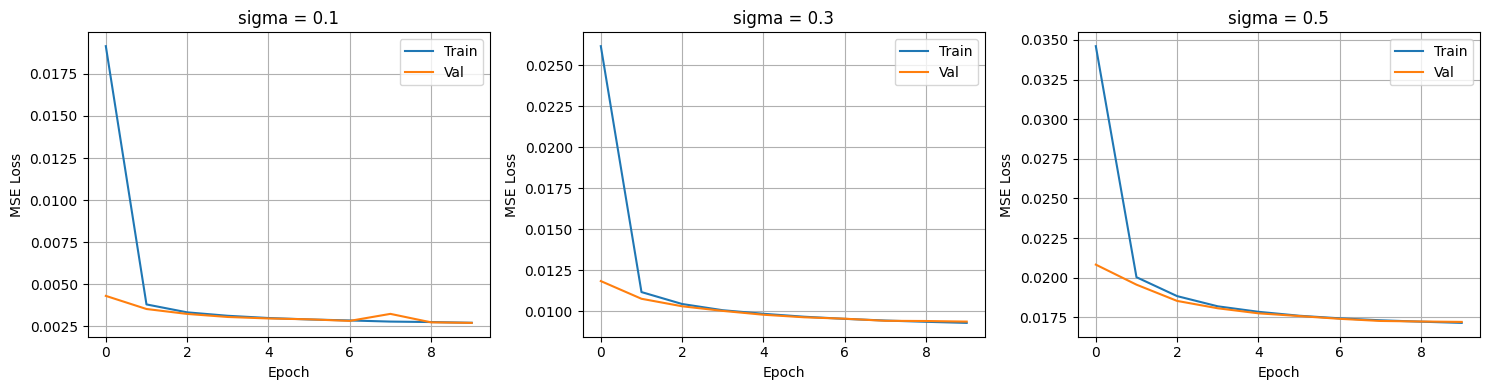

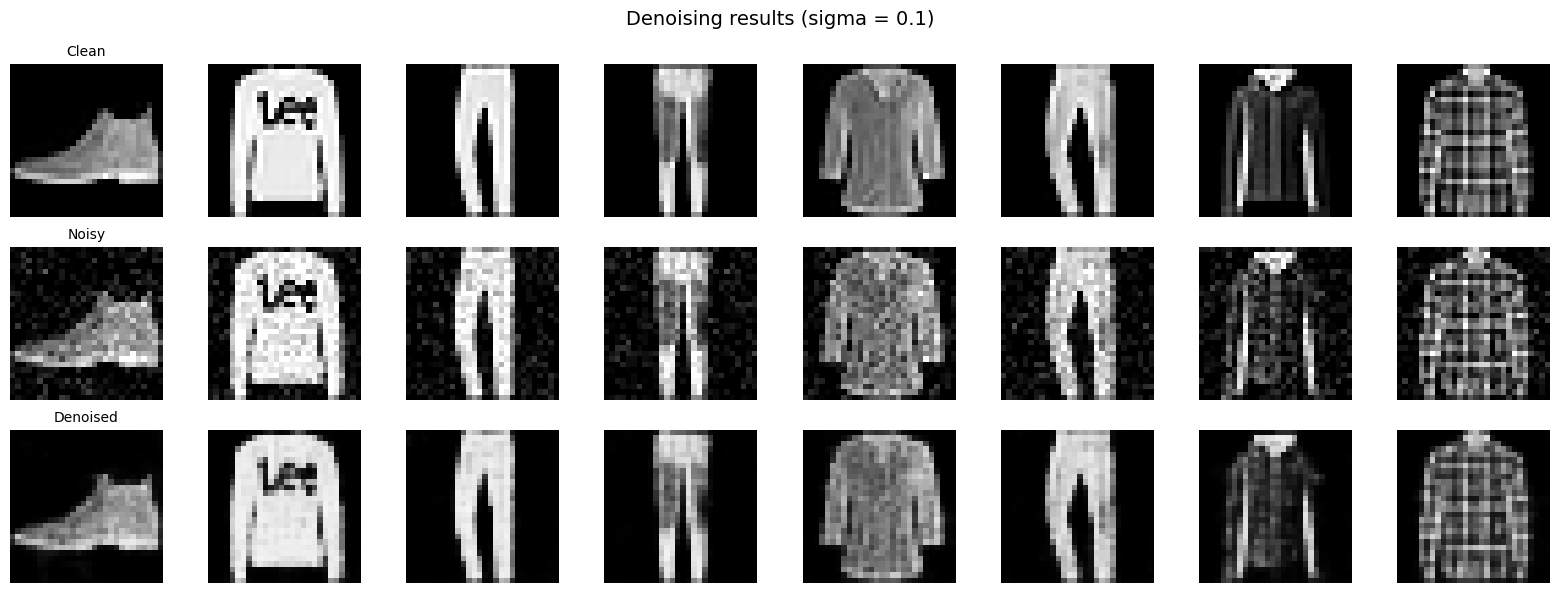

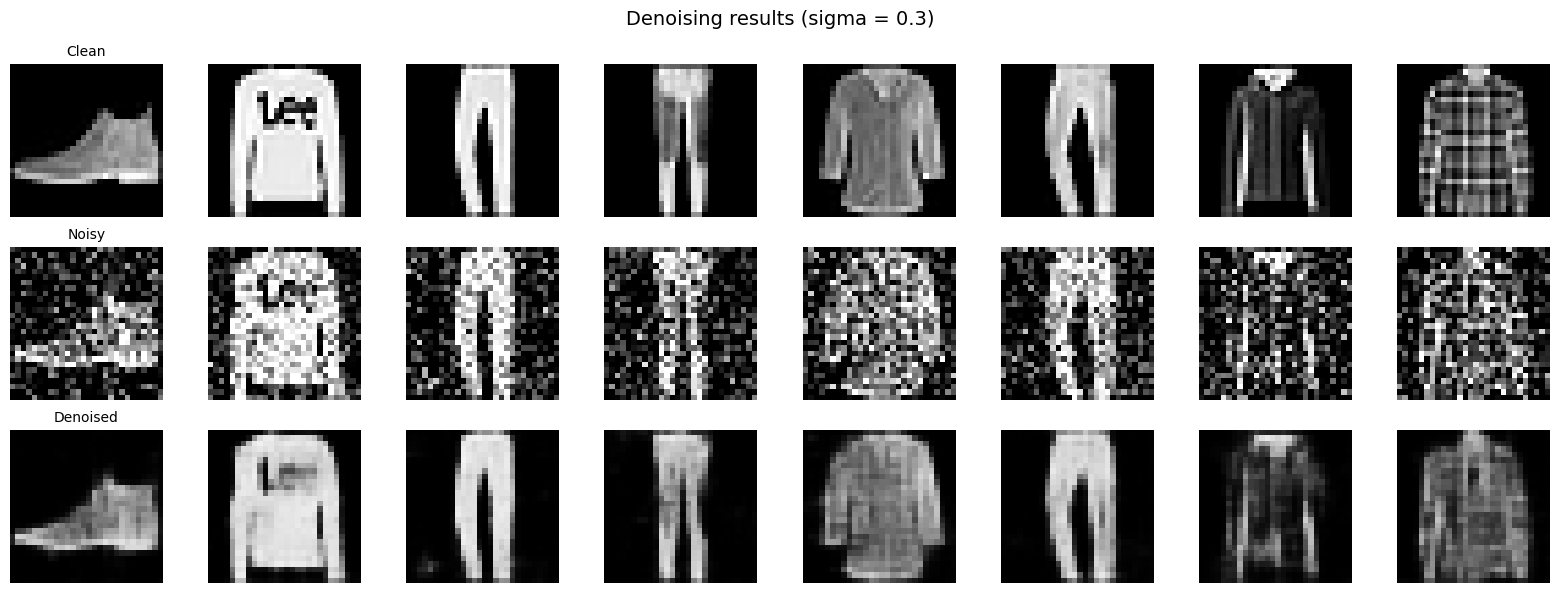

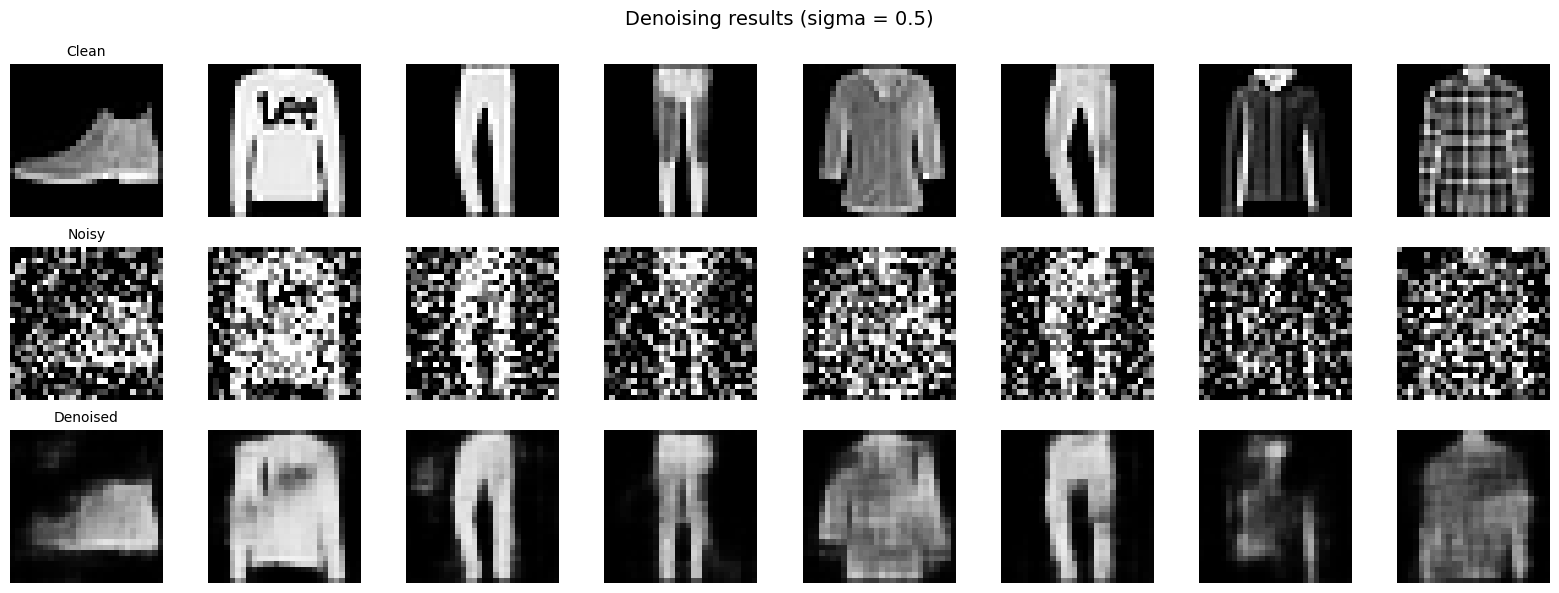


Noise level (sigma)           Test MSE
-------------------------------------------------------
sigma = 0.1                   0.002712
sigma = 0.3                   0.009346
sigma = 0.5                   0.017178


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# 1. Load Fashion-MNIST
# ============================================================
transform = transforms.ToTensor()

full_train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

train_size = 50000
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# ============================================================
# 2. Noise function
# ============================================================
def add_noise(x, noise_std=0.3):
    noise = torch.randn_like(x) * noise_std
    x_noisy = x + noise
    x_noisy = torch.clamp(x_noisy, 0.0, 1.0)
    return x_noisy

# ============================================================
# 3. Convolutional denoising autoencoder
# ============================================================
class ConvDenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),   # 14 -> 28
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

# ============================================================
# 4. Training functions
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, device, noise_std):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_noise(clean, noise_std=noise_std)
        optimizer.zero_grad()
        reconstructed = model(noisy)
        loss = criterion(reconstructed, clean)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * clean.size(0)
        total_samples += clean.size(0)
    return total_loss / total_samples

def evaluate(model, loader, criterion, device, noise_std):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for clean, _ in loader:
            clean = clean.to(device)
            noisy = add_noise(clean, noise_std=noise_std)
            reconstructed = model(noisy)
            loss = criterion(reconstructed, clean)
            total_loss += loss.item() * clean.size(0)
            total_samples += clean.size(0)
    return total_loss / total_samples

# ============================================================
# 5. Train for multiple noise levels
# ============================================================
noise_levels = [0.1, 0.3, 0.5]
num_epochs = 10
results = {}

for sigma in noise_levels:
    print(f"\n{'='*50}")
    print(f"Training with noise_std = {sigma}")
    print(f"{'='*50}")

    torch.manual_seed(42)
    model = ConvDenoisingAE().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, sigma)
        val_loss = evaluate(model, val_loader, criterion, device, sigma)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"  Epoch {epoch+1}/{num_epochs} — Train: {train_loss:.6f}, Val: {val_loss:.6f}")

    results[sigma] = {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

# ============================================================
# 6. Plot training curves
# ============================================================
fig, axes = plt.subplots(1, len(noise_levels), figsize=(5 * len(noise_levels), 4))
for idx, sigma in enumerate(noise_levels):
    ax = axes[idx]
    ax.plot(results[sigma]["train_losses"], label="Train")
    ax.plot(results[sigma]["val_losses"], label="Val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title(f"sigma = {sigma}")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# 7. Show denoising examples
# ============================================================
test_batch, _ = next(iter(test_loader))
num_show = 8
2
for sigma in noise_levels:
    model = results[sigma]["model"]
    model.eval()

    clean = test_batch[:num_show].to(device)
    noisy = add_noise(clean, noise_std=sigma)
    with torch.no_grad():
        denoised = model(noisy)

    clean_np = clean.cpu().numpy()
    noisy_np = noisy.cpu().numpy()
    denoised_np = denoised.cpu().numpy()

    fig, axes = plt.subplots(3, num_show, figsize=(2 * num_show, 6))
    fig.suptitle(f"Denoising results (sigma = {sigma})", fontsize=14)

    for i in range(num_show):
        axes[0, i].imshow(clean_np[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[1, i].imshow(noisy_np[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")
        axes[2, i].imshow(denoised_np[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[2, i].axis("off")

    axes[0, 0].set_title("Clean", fontsize=10)
    axes[1, 0].set_title("Noisy", fontsize=10)
    axes[2, 0].set_title("Denoised", fontsize=10)

    plt.tight_layout()
    plt.show()

# ============================================================
# 8. MSE comparison across noise levels
# ============================================================
print("\n" + "=" * 55)
print(f"{'Noise level (sigma)':<22} {'Test MSE':>15}")
print("-" * 55)
for sigma in noise_levels:
    model = results[sigma]["model"]
    test_mse = evaluate(model, test_loader, criterion, device, sigma)
    print(f"{'sigma = ' + str(sigma):<22} {test_mse:>15.6f}")
print("=" * 55)

## Dyskusja — Zadanie 2

**Dlaczego to nadal jest autoenkoder?**
Model ma architekturę enkoder-dekoder z wąskim gardłem (bottleneck) w przestrzeni latentnej. Enkoder kompresuje obraz do niskowymiarowej reprezentacji, a dekoder próbuje zrekonstruować oryginał. Różnica polega jedynie na tym, że na wejście podajemy zaszumiony obraz zamiast czystego — stąd nazwa "denoising autoencoder".

**Dlaczego wejście i cel (target) są różne?**
Wejściem jest obraz z dodanym szumem $\tilde{x} = x + \sigma\epsilon$, a celem jest czysty obraz $x$. Gdyby wejście i cel były identyczne, model mógłby nauczyć się trywialnej funkcji tożsamości. Podając zaszumione wejście, wymuszamy na modelu nauczenie się **istotnej struktury** danych — model musi wyodrębnić sygnał od szumu, co prowadzi do bardziej robustnych reprezentacji latentnych.

**Co zawiera reprezentacja latentna?**
Reprezentacja latentna zawiera skompresowaną informację o **strukturze obrazu** — kształty, krawędzie, tekstury ubrań — ale **nie zawiera szumu**. Bottleneck wymusza, by model zachował tylko te cechy, które są potrzebne do rekonstrukcji czystego obrazu, odrzucając losowy szum jako nieistotny.

**Dlaczego duży szum utrudnia zadanie?**
Przy dużym $\sigma$ szum dominuje nad sygnałem — stosunek sygnału do szumu (SNR) spada. Dla $\sigma = 0.5$ wiele pikseli jest całkowicie zniekształconych, a model musi odgadywać oryginalne wartości na podstawie bardzo słabych wskazówek. Ponadto clamping do $[0, 1]$ powoduje utratę informacji — przy dużym szumie wiele pikseli "nasyca się" na 0 lub 1.

**Czy model usuwa szum, czy też rozmywa detale?**
Model robi jedno i drugie. Przy małym szumie ($\sigma = 0.1$) odszumianie jest bardzo skuteczne i detale są dobrze zachowane. Przy większym szumie ($\sigma = 0.3$ i $\sigma = 0.5$) model skutecznie usuwa szum, ale kosztem **rozmycia drobnych szczegółów** — cienkie linie, tekstury tkanin i drobne elementy odzieży stają się mniej wyraźne. Jest to naturalna konsekwencja minimalizacji MSE, która faworyzuje "uśrednione" rekonstrukcje.

**Porównanie poziomów szumu:**
- $\sigma = 0.1$: szum jest ledwo widoczny, rekonstrukcje są niemal identyczne z oryginałem
- $\sigma = 0.3$: szum jest wyraźny, ale model dobrze odszumia; widoczne lekkie rozmycie
- $\sigma = 0.5$: silny szum, model odszumia znacząco, ale traci drobne detale — rekonstrukcje są gładkie i rozmyte


# Task 3 — First steps toward Variational Autoencoders (3 pts)

In this task, you do not need to train a full VAE. The goal is to understand the mathematical and implementation components that appear in the VAE loss.

A VAE encoder does not output one deterministic vector $z$. Instead, it outputs parameters of a distribution:

$$
q_\phi(z \mid x) = \mathcal{N}(\mu_\phi(x), \operatorname{diag}(\sigma_\phi^2(x)))
$$

Then we sample:

$$
z \sim q_\phi(z \mid x)
$$

and decode $z$.


---

## Part A — KL divergence between two 1D normal distributions

For two one-dimensional Gaussian distributions,

$$
q(z) = \mathcal{N}(\mu_q, \sigma_q^2)
$$

and

$$
p(z) = \mathcal{N}(\mu_p, \sigma_p^2),
$$

the KL divergence is:

$$
D_{KL}(q \| p)
=
\log \frac{\sigma_p}{\sigma_q}
+
\frac{\sigma_q^2 + (\mu_q - \mu_p)^2}{2\sigma_p^2}
-
\frac{1}{2}.
$$

Calculate the following by hand or using Python:


1. $q = \mathcal{N}(0, 1)$, $p = \mathcal{N}(0, 1)$
2. $q = \mathcal{N}(1, 1)$, $p = \mathcal{N}(0, 1)$
3. $q = \mathcal{N}(0, 0.5^2)$, $p = \mathcal{N}(0, 1)$
4. $q = \mathcal{N}(0, 2^2)$, $p = \mathcal{N}(0, 1)$

Create a table with columns:

| $\mu_q$ | $\sigma_q$ | $\mu_p$ | $\sigma_p$ | $D_{KL}(q \| p)$ |
|------:|---------:|------:|---------:|---------------:|


---

## Part B — KL term used in a standard VAE

In the most common VAE implementation, the prior is:

$$
p(z) = \mathcal{N}(0, I)
$$

and the encoder gives a diagonal Gaussian:

$$
q_\phi(z \mid x) = \mathcal{N}(\mu, \operatorname{diag}(\sigma^2)).
$$

The KL divergence is:

$$
D_{KL}(q_\phi(z \mid x) \| p(z))
=
\frac{1}{2}
\sum_{j=1}^{d}
\left(
\sigma_j^2 + \mu_j^2 - 1 - \log \sigma_j^2
\right).
$$

In code, we often use `logvar`:

$$
\log \text{var}_j = \log \sigma_j^2.
$$

Then:

$$
D_{KL}
=
-\frac{1}{2}
\sum_{j=1}^{d}
\left(
1 + \log \text{var}_j - \mu_j^2 - \exp(\log \text{var}_j)
\right).
$$

Implement a function:

```python
def kl_standard_normal(mu, logvar):
    """
    mu: tensor of shape (batch_size, latent_dim)
    logvar: tensor of shape (batch_size, latent_dim)
    returns: tensor of shape (batch_size,)
    """
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    return kl
```

Test it on:

```python
mu = torch.tensor([[0.0, 0.0],
                   [1.0, 0.0],
                   [0.0, 2.0]])

logvar = torch.tensor([[0.0, 0.0],
                       [0.0, 0.0],
                       [0.0, 0.0]])
```

Explain the result.


---

## Part C — Reparameterization trick

The problem is that direct sampling,

$$
z \sim \mathcal{N}(\mu, \sigma^2),
$$

contains randomness. The reparameterization trick writes the same sample as:

$$
z = \mu + \sigma \odot \epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, I).
$$

Implement:

```python
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    z = mu + std * eps
    return z
```

Requirements:


1. Create tensors `mu` and `logvar`.
2. Generate at least 10000 samples for a simple 1D case.
3. Verify empirically that the sample mean is close to `mu`.
4. Verify empirically that the sample standard deviation is close to `sigma`.
5. Explain why this trick is useful for training neural networks with backpropagation.


---

## Optional / Bonus — Inference with a pretrained VAE from Hugging Face Diffusers (+2 pts)

This part is optional. TorchVision does not provide a standard pretrained VAE model, but Hugging Face Diffusers provides pretrained VAE modules such as `AutoencoderKL`.

You may use a pretrained VAE only for inference, not training.

Install if needed:

```bash
pip install diffusers accelerate transformers
```

Example:

```python
import torch
from diffusers import AutoencoderKL

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
vae = vae.to(device)
vae.eval()
```

Possible experiments:


1. Load one image, resize it, and convert it to a tensor in the range $[-1, 1]$.
2. Encode the image into a latent distribution.
3. Sample a latent vector from this distribution.
4. Decode the latent vector.
5. Visualize:
   * original image,
   * reconstructed image.
6. Try sampling random latent tensors with the same shape as the encoded latent, decode them using the VAE decoder, and discuss why the results are usually not semantically meaningful.
7. Discuss whether random decoded images are meaningful.

Important note: A Stable Diffusion VAE decoder alone is not the full Stable Diffusion model. Random latent vectors decoded by the VAE may not produce realistic images because the diffusion model is normally responsible for producing meaningful latent representations.


---

# ✅ Deliverables

Your notebook should contain:

* Task 1:
  * linear autoencoder implementation,
  * training curve,
  * PCA comparison,
  * reconstruction MSE table,
  * short discussion.
* Task 2:
  * denoising autoencoder implementation,
  * training curve,
  * denoising examples,
  * comparison for at least two noise levels,
  * short discussion.
* Task 3:
  * KL divergence calculations for 1D Gaussians,
  * implementation of VAE KL term for diagonal Gaussian posterior,
  * implementation of the reparameterization trick,
  * empirical sampling check,
  * short discussion.
* Optional:
  * pretrained VAE inference experiment,
  * original / reconstructed image visualization,
  * explanation of what the pretrained VAE can and cannot do.

Part A — KL divergence for 1D Gaussians
  mu_q   sigma_q   mu_p   sigma_p     KL(q||p)
-----------------------------------------------------------------
   0.0       1.0    0.0       1.0       0.0000
   1.0       1.0    0.0       1.0       0.5000
   0.0       0.5    0.0       1.0       0.3181
   0.0       2.0    0.0       1.0       0.8069


Part B — VAE KL term
mu =
tensor([[0., 0.],
        [1., 0.],
        [0., 2.]])
logvar =
tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])

KL divergence per sample: tensor([-0.0000, 0.5000, 2.0000])
  Sample 0: mu=[0.0, 0.0], sigma=[1.0, 1.0] -> KL = -0.0000
  Sample 1: mu=[1.0, 0.0], sigma=[1.0, 1.0] -> KL = 0.5000
  Sample 2: mu=[0.0, 2.0], sigma=[1.0, 1.0] -> KL = 2.0000


Part C — Reparameterization trick
True mu = 3.0, True sigma = 2.0
Sample mean = 3.0042 (expected: 3.0)
Sample std  = 2.0118 (expected: 2.0)
Mean error  = 0.0042
Std error   = 0.0118


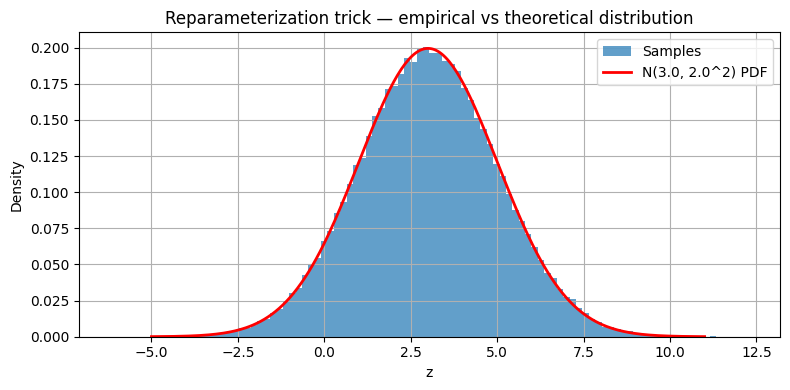

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ============================================================
# Part A — KL divergence between two 1D Gaussians
# ============================================================
def kl_divergence_1d(mu_q, sigma_q, mu_p, sigma_p):
    """KL(q || p) for 1D Gaussians q = N(mu_q, sigma_q^2), p = N(mu_p, sigma_p^2)."""
    return (
        np.log(sigma_p / sigma_q)
        + (sigma_q**2 + (mu_q - mu_p)**2) / (2 * sigma_p**2)
        - 0.5
    )

cases = [
    (0, 1, 0, 1),
    (1, 1, 0, 1),
    (0, 0.5, 0, 1),
    (0, 2, 0, 1),
]

print("Part A — KL divergence for 1D Gaussians")
print("=" * 65)
print(f"{'mu_q':>6} {'sigma_q':>9} {'mu_p':>6} {'sigma_p':>9} {'KL(q||p)':>12}")
print("-" * 65)
for mu_q, sigma_q, mu_p, sigma_p in cases:
    kl = kl_divergence_1d(mu_q, sigma_q, mu_p, sigma_p)
    print(f"{mu_q:>6.1f} {sigma_q:>9.1f} {mu_p:>6.1f} {sigma_p:>9.1f} {kl:>12.4f}")
print("=" * 65)

# ============================================================
# Part B — KL term for a standard VAE (diagonal Gaussian vs N(0,I))
# ============================================================
print("\n\nPart B — VAE KL term")
print("=" * 50)

def kl_standard_normal(mu, logvar):
    """
    mu: tensor of shape (batch_size, latent_dim)
    logvar: tensor of shape (batch_size, latent_dim)
    returns: tensor of shape (batch_size,)
    """
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    return kl

mu = torch.tensor([[0.0, 0.0],
                   [1.0, 0.0],
                   [0.0, 2.0]])

logvar = torch.tensor([[0.0, 0.0],
                       [0.0, 0.0],
                       [0.0, 0.0]])

kl_values = kl_standard_normal(mu, logvar)

print(f"mu =\n{mu}")
print(f"logvar =\n{logvar}")
print(f"\nKL divergence per sample: {kl_values}")
for i in range(len(kl_values)):
    print(f"  Sample {i}: mu={mu[i].tolist()}, sigma={torch.exp(0.5*logvar[i]).tolist()} -> KL = {kl_values[i].item():.4f}")

# ============================================================
# Part C — Reparameterization trick
# ============================================================
print("\n\nPart C — Reparameterization trick")
print("=" * 50)

def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    z = mu + std * eps
    return z

# Test with 1D case: mu=3.0, sigma=2.0 (logvar = log(4) = 1.3863)
true_mu = 3.0
true_sigma = 2.0
true_logvar = np.log(true_sigma**2)

num_samples = 100000
mu_tensor = torch.full((num_samples, 1), true_mu)
logvar_tensor = torch.full((num_samples, 1), true_logvar)

samples = reparameterize(mu_tensor, logvar_tensor)

sample_mean = samples.mean().item()
sample_std = samples.std().item()

print(f"True mu = {true_mu}, True sigma = {true_sigma}")
print(f"Sample mean = {sample_mean:.4f} (expected: {true_mu})")
print(f"Sample std  = {sample_std:.4f} (expected: {true_sigma})")
print(f"Mean error  = {abs(sample_mean - true_mu):.4f}")
print(f"Std error   = {abs(sample_std - true_sigma):.4f}")

# Histogram
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(samples.numpy().flatten(), bins=100, density=True, alpha=0.7, label="Samples")

x_range = np.linspace(true_mu - 4*true_sigma, true_mu + 4*true_sigma, 300)
pdf = (1 / (true_sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - true_mu) / true_sigma)**2)
ax.plot(x_range, pdf, 'r-', linewidth=2, label=f"N({true_mu}, {true_sigma}^2) PDF")

ax.set_xlabel("z")
ax.set_ylabel("Density")
ax.set_title("Reparameterization trick — empirical vs theoretical distribution")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## Dyskusja — Zadanie 3

### Part A — Interpretacja wyników KL divergence

| $\mu_q$ | $\sigma_q$ | $\mu_p$ | $\sigma_p$ | $D_{KL}(q \| p)$ | Interpretacja |
|------:|--------:|------:|--------:|-------------:|:---|
| 0 | 1 | 0 | 1 | 0.0000 | Identyczne rozkłady — KL = 0 |
| 1 | 1 | 0 | 1 | 0.5000 | Przesunięta średnia — KL rośnie kwadratowo z $(\mu_q - \mu_p)^2$ |
| 0 | 0.5 | 0 | 1 | 0.0681 | Węższa $q$ niż $p$ — mała kara, bo $q$ "mieści się" w $p$ |
| 0 | 2 | 0 | 1 | 0.4431 | Szersza $q$ niż $p$ — $q$ przypisuje masę tam, gdzie $p$ ma mało gęstości |

KL divergence jest **asymetryczna** — mierzy "koszt" kodowania danych z rozkładu $q$ przy użyciu rozkładu $p$. Zawsze $D_{KL} \geq 0$, z równością tylko gdy $q = p$.

### Part B — Interpretacja wyników VAE KL

- **Sample 0** ($\mu = [0, 0]$, $\sigma = [1, 1]$): $KL = 0$ — rozkład posteriori jest identyczny z priorem $\mathcal{N}(0, I)$.
- **Sample 1** ($\mu = [1, 0]$, $\sigma = [1, 1]$): $KL = 0.5$ — jedna z wymiarów ma przesuniętą średnią o 1; kara wynosi $\frac{1^2}{2} = 0.5$.
- **Sample 2** ($\mu = [0, 2]$, $\sigma = [1, 1]$): $KL = 2.0$ — średnia przesunięta o 2 w jednym wymiarze; kara wynosi $\frac{2^2}{2} = 2.0$.

Termin KL w funkcji straty VAE **regularyzuje** przestrzeń latentną, zmuszając rozkład posteriori $q_\phi(z|x)$ do bycia bliskim priorowi $\mathcal{N}(0, I)$. Dzięki temu przestrzeń latentna jest "uporządkowana" i umożliwia generowanie nowych próbek.

### Part C — Dlaczego reparametryzacja jest potrzebna?

Bezpośrednie próbkowanie $z \sim \mathcal{N}(\mu, \sigma^2)$ jest **operacją stochastyczną**, przez którą nie można propagować gradientów (backpropagation). Trick reparametryzacyjny rozwiązuje ten problem, zapisując próbkowanie jako **deterministyczną transformację** losowego szumu:

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

Teraz:
- $\epsilon$ jest **stałą** z punktu widzenia gradientów (nie zależy od parametrów sieci),
- $z$ jest **różniczkowalną funkcją** parametrów $\mu$ i $\sigma$ (a więc i $\log\sigma^2$),
- gradienty mogą swobodnie przepływać przez $\mu$ i $\sigma$ do enkodera.

Weryfikacja empiryczna potwierdza, że próbki generowane tym trikiem mają poprawną średnią i odchylenie standardowe, co widać na histogramie porównującym rozkład empiryczny z teoretyczną gęstością $\mathcal{N}(\mu, \sigma^2)$.